In [5]:
import numpy as np

總共抓取了 1024 個取樣點。
轉換後的 PyTorch Tensor 形狀是: torch.Size([2, 1024])
------------------------------


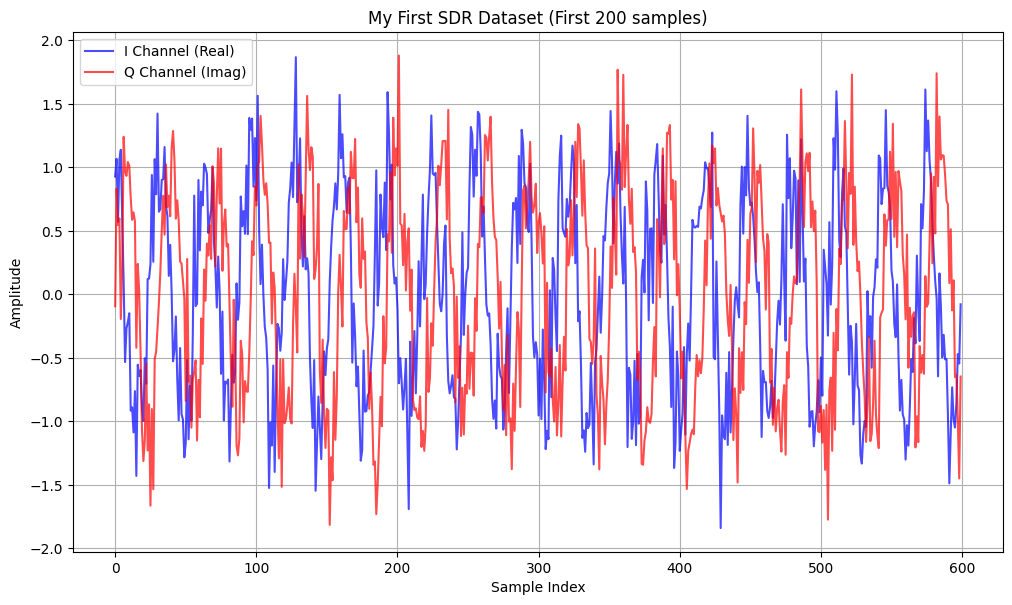

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. 設定檔案路徑 (請換成你實際的 .dat 檔案路徑)
file_path = r"C:\Users\eric0\Desktop\project1_dataset\test_signal_01\sig_1.dat" 

# 2. 讀取二進位檔案
# GNU Radio 的複數 (Complex) 是由兩個 32-bit 浮點數組成
# 所以我們用 np.complex64 來完美接住它！
raw_data = np.fromfile(file_path, dtype=np.complex64)

# 3. 核心步驟：把複數拆解成 AI 看得懂的 I 和 Q 兩個頻道
I_channel = raw_data.real  # 實部 (In-phase)
Q_channel = raw_data.imag  # 虛部 (Quadrature)

# 4. 把它們疊起來，變成神經網路需要的形狀 [Channels, Sequence_Length]
ai_input_numpy = np.vstack((I_channel, Q_channel))

# 5. 直接轉成 PyTorch Tensor！
ai_tensor = torch.tensor(ai_input_numpy, dtype=torch.float32)

print(f"總共抓取了 {len(raw_data)} 個取樣點。")
print(f"轉換後的 PyTorch Tensor 形狀是: {ai_tensor.shape}")
print("-" * 30)

# 6. 畫出前 200 個點來驗證一下 (點數太多會畫很久，200點剛剛好)
plt.figure(figsize=(12, 6.75))
plt.plot(I_channel[:600], label='I Channel (Real)', color='blue', alpha=0.7)
plt.plot(Q_channel[:600], label='Q Channel (Imag)', color='red', alpha=0.7)
plt.title("My First SDR Dataset (First 200 samples)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()